In [22]:
library(msigdbr)
library(data.table)
# library(org.Hs.eg.db)
# library(circlize)
library(ComplexHeatmap)
library(clusterProfiler)

source("/mnt/lareaulab/reliscu/code/fisher_test.R")

In [ ]:
gs_GO <- msigdbr(collection="C5") # , subcollection="GO:BP")
gs_GO_list <- tapply(gs_GO$gene_symbol, INDEX=gs_GO$gs_name, FUN=list)
gs_GO_list <- gs_GO_list[grep("^HP", names(gs_GO_list), invert=TRUE)]
gs_GO_list <- gs_GO_list[grep("^GOCC", names(gs_GO_list), invert=TRUE)]
min_set_size <- 5
max_set_size <- 200

set_sizes <- lengths(gs_GO_list)
mask <- (set_sizes < max_set_size) & (set_sizes > min_set_size)
gs_GO_list <- gs_GO_list[mask]

print(length(gs_GO_list))

In [4]:
psi_corr_df <- fread("data/ctype_exons/exon_PSI_abundance_correlations.csv", data.table=FALSE)
psi_fdr_df <- fread("data/ctype_exons/exon_PSI_abundance_correlation_FDRs.csv", data.table=FALSE)

In [ ]:
# library(factoextra)
# library(cluster)

# # try k from 2 to 10
# k_range <- 2:10

# # silhouette scores (higher = better separation)
# sil_scores <- sapply(k_range, function(k) {
#   clusters <- cutree(hc, k = k)
#   mean(silhouette(clusters, d)[, 3])
# })

# plot(k_range, sil_scores, type = "b", pch = 19,
#      xlab = "k", ylab = "Mean silhouette score",
#      main = "Silhouette method")
# abline(v = k_range[which.max(sil_scores)], lty = 2, col = "red")

In [68]:
ct_inds <- c(3, 6:ncol(psi_corr_df))

rows_to_keep <- apply(psi_fdr_df[,ct_inds], 1, function(row) {
    if(any(row == 0) & var(row) > 0) {
        return(TRUE)
    } else {
        return(FALSE)
    }
})
print(sum(rows_to_keep))

rownames(psi_corr_df) <- psi_corr_df[,1]
corr_mat <- cor(t(psi_corr_df[rows_to_keep, ct_inds]))

sample_idx <- sample(1:ncol(corr_mat), size=5000)
corr_mat_subset <- corr_mat[sample_idx, sample_idx]
d <- as.dist(1 - corr_mat_subset)
hc <- hclust(d, method="ward.D2")

k <- 6
clusters <- cutree(hc, k = k)

ctype_corrs <- lapply(ct_inds, function(x) psi_corr_df[sample_idx, x, drop=TRUE])
names(ctype_corrs) <- colnames(psi_corr_df)[ct_inds]
ctype_corrs <- psi_corr_df[sample_idx, ct_inds]

[1] 11523


In [ ]:
background <- psi_corr_df$Gene[sample_idx]
cluster_genes <- tapply(background, clusters, list)

i <- 1

enrich_res_list <- lapply(unlist(lapply(gs_GO_list, function(set) {
    fisher_test(set, cluster_genes[[i]], all=background)
})), c)
    
enrich_df <- reshape2::melt(enrich_res_list)
# enrich_df$Qval <- qvalue(enrich_df$Pval)$qvalue

enrich_df %>% arrange(value)

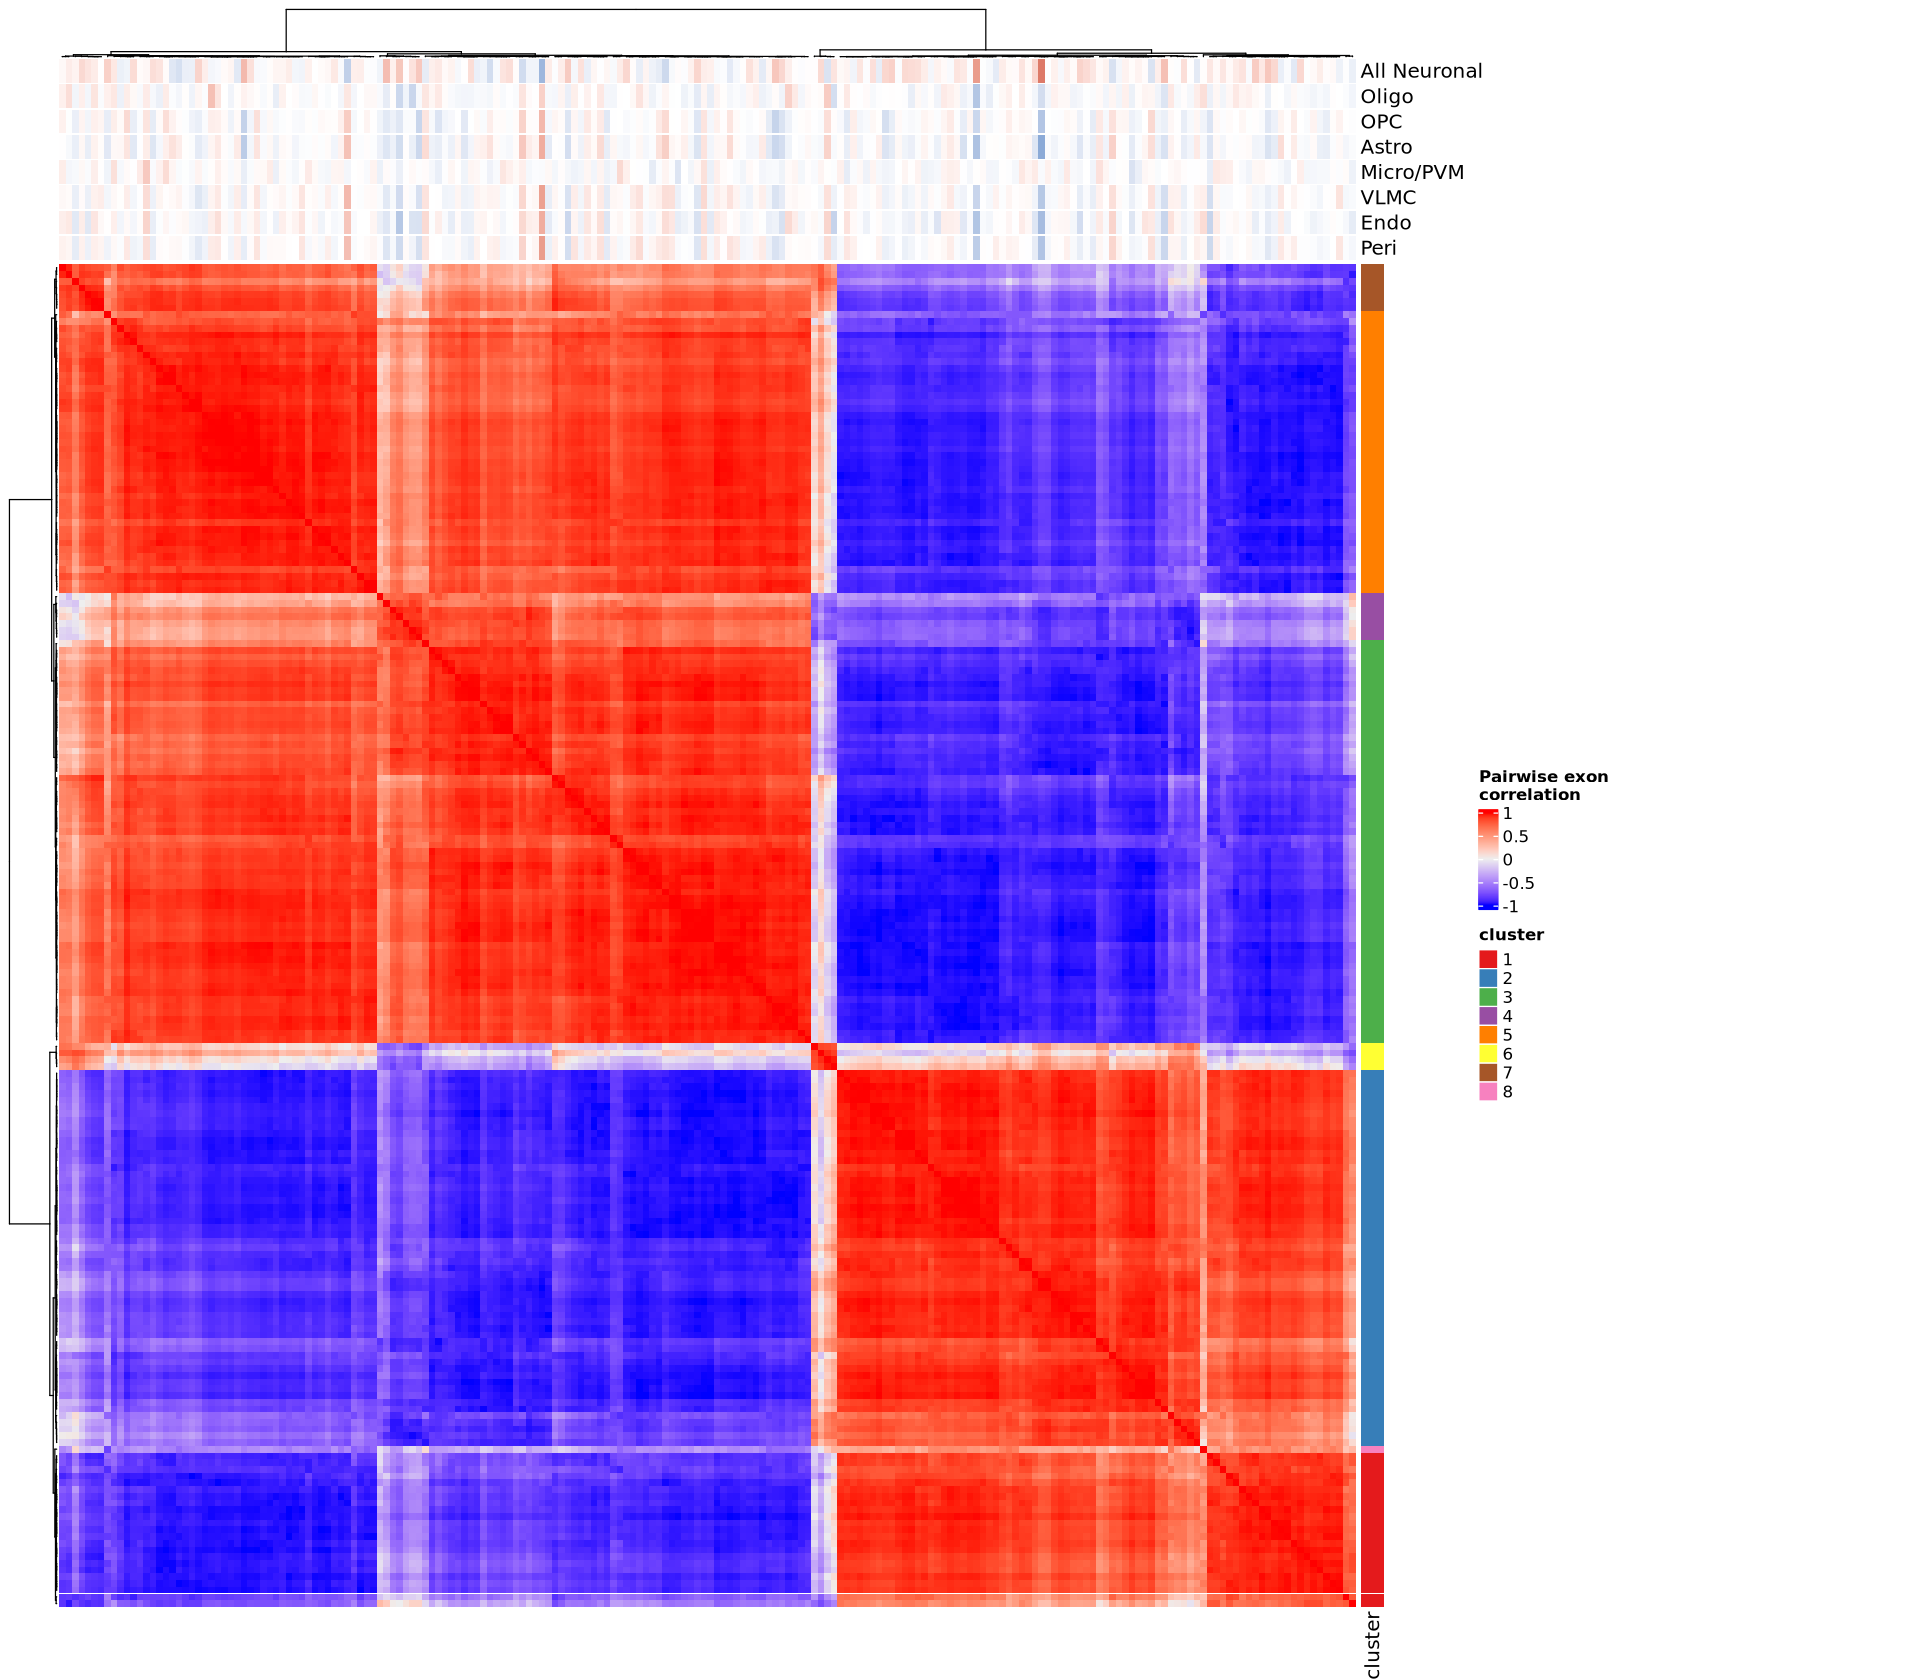

In [100]:
# # Sample annotation (e.g. condition, cell type)
col_anno <- do.call(HeatmapAnnotation, c(
  ctype_corrs,
  list(col = lapply(ctype_corrs, function(x) 
    circlize::colorRamp2(c(-1, 0, 1), c("#3A7EC0", "white", "#C1392B"))
  )),
  show_legend = FALSE
))

row_anno <- rowAnnotation(
  cluster = as.character(clusters),
  col = list(cluster = setNames(
    RColorBrewer::brewer.pal(k, "Set1"),
    as.character(1:k)
  ))
)

# # Row annotation: cluster membership
# row_anno <- rowAnnotation(
#   cluster = as.character(clusters),
#   col = list(cluster = setNames(
#     RColorBrewer::brewer.pal(4, "Set2"),
#     as.character(1:4)
#   ))
# )

options(repr.plot.width=16, repr.plot.height=14)

ht <- Heatmap(
  corr_mat_subset,
  name            = "Pairwise exon\ncorrelation",
  top_annotation  = col_anno,
  right_annotation = row_anno,
  cluster_rows    = hc,       # pass your hclust object
  cluster_columns = hc,
  show_row_names  = FALSE,        # hide if many exons
  show_column_names = FALSE,
#   row_split = clusters,     # draws gaps between clusters
#   column_split = clusters,
  border = FALSE
)

draw(ht, padding = unit(c(2, 2, 2, 70), "mm"))  # increase right value until labels fit

In [79]:
ct_inds <- 3:7

rows_to_keep <- apply(psi_fdr_df[,ct_inds], 1, function(row) {
    if(any(row == 0) & var(row) > 0) {
        return(TRUE)
    } else {
        return(FALSE)
    }
})


rownames(psi_corr_df) <- psi_corr_df[,1]
corr_mat <- cor(t(psi_corr_df[rows_to_keep, ct_inds]))

sample_idx <- sample(1:ncol(corr_mat), size=2000)
corr_mat_subset <- corr_mat[sample_idx, sample_idx]
d <- as.dist(1 - corr_mat_subset)
hc <- hclust(d, method="ward.D2")

k  <- 6
clusters <- cutree(hc, k = k)
 
ctype_corrs <- lapply(3:ncol(psi_corr_df), function(x) psi_corr_df[sample_idx,x, drop=TRUE])
names(ctype_corrs) <- colnames(psi_corr_df)[3:ncol(psi_corr_df)]
ctype_corrs <- psi_corr_df[sample_idx, 3:ncol(psi_corr_df)][,c(1:5)]

In [ ]:
background <- psi_corr_df$Gene[sample_idx]
cluster_genes <- tapply(background, clusters, list)

i <- 2

enrich_res_list <- lapply(unlist(lapply(gs_GO_list, function(set) {
    fisher_test(set, cluster_genes[[i]], all=background)
})), c)
    
enrich_df <- reshape2::melt(enrich_res_list)
# enrich_df$Qval <- qvalue(enrich_df$Pval)$qvalue

enrich_df %>% arrange(value)

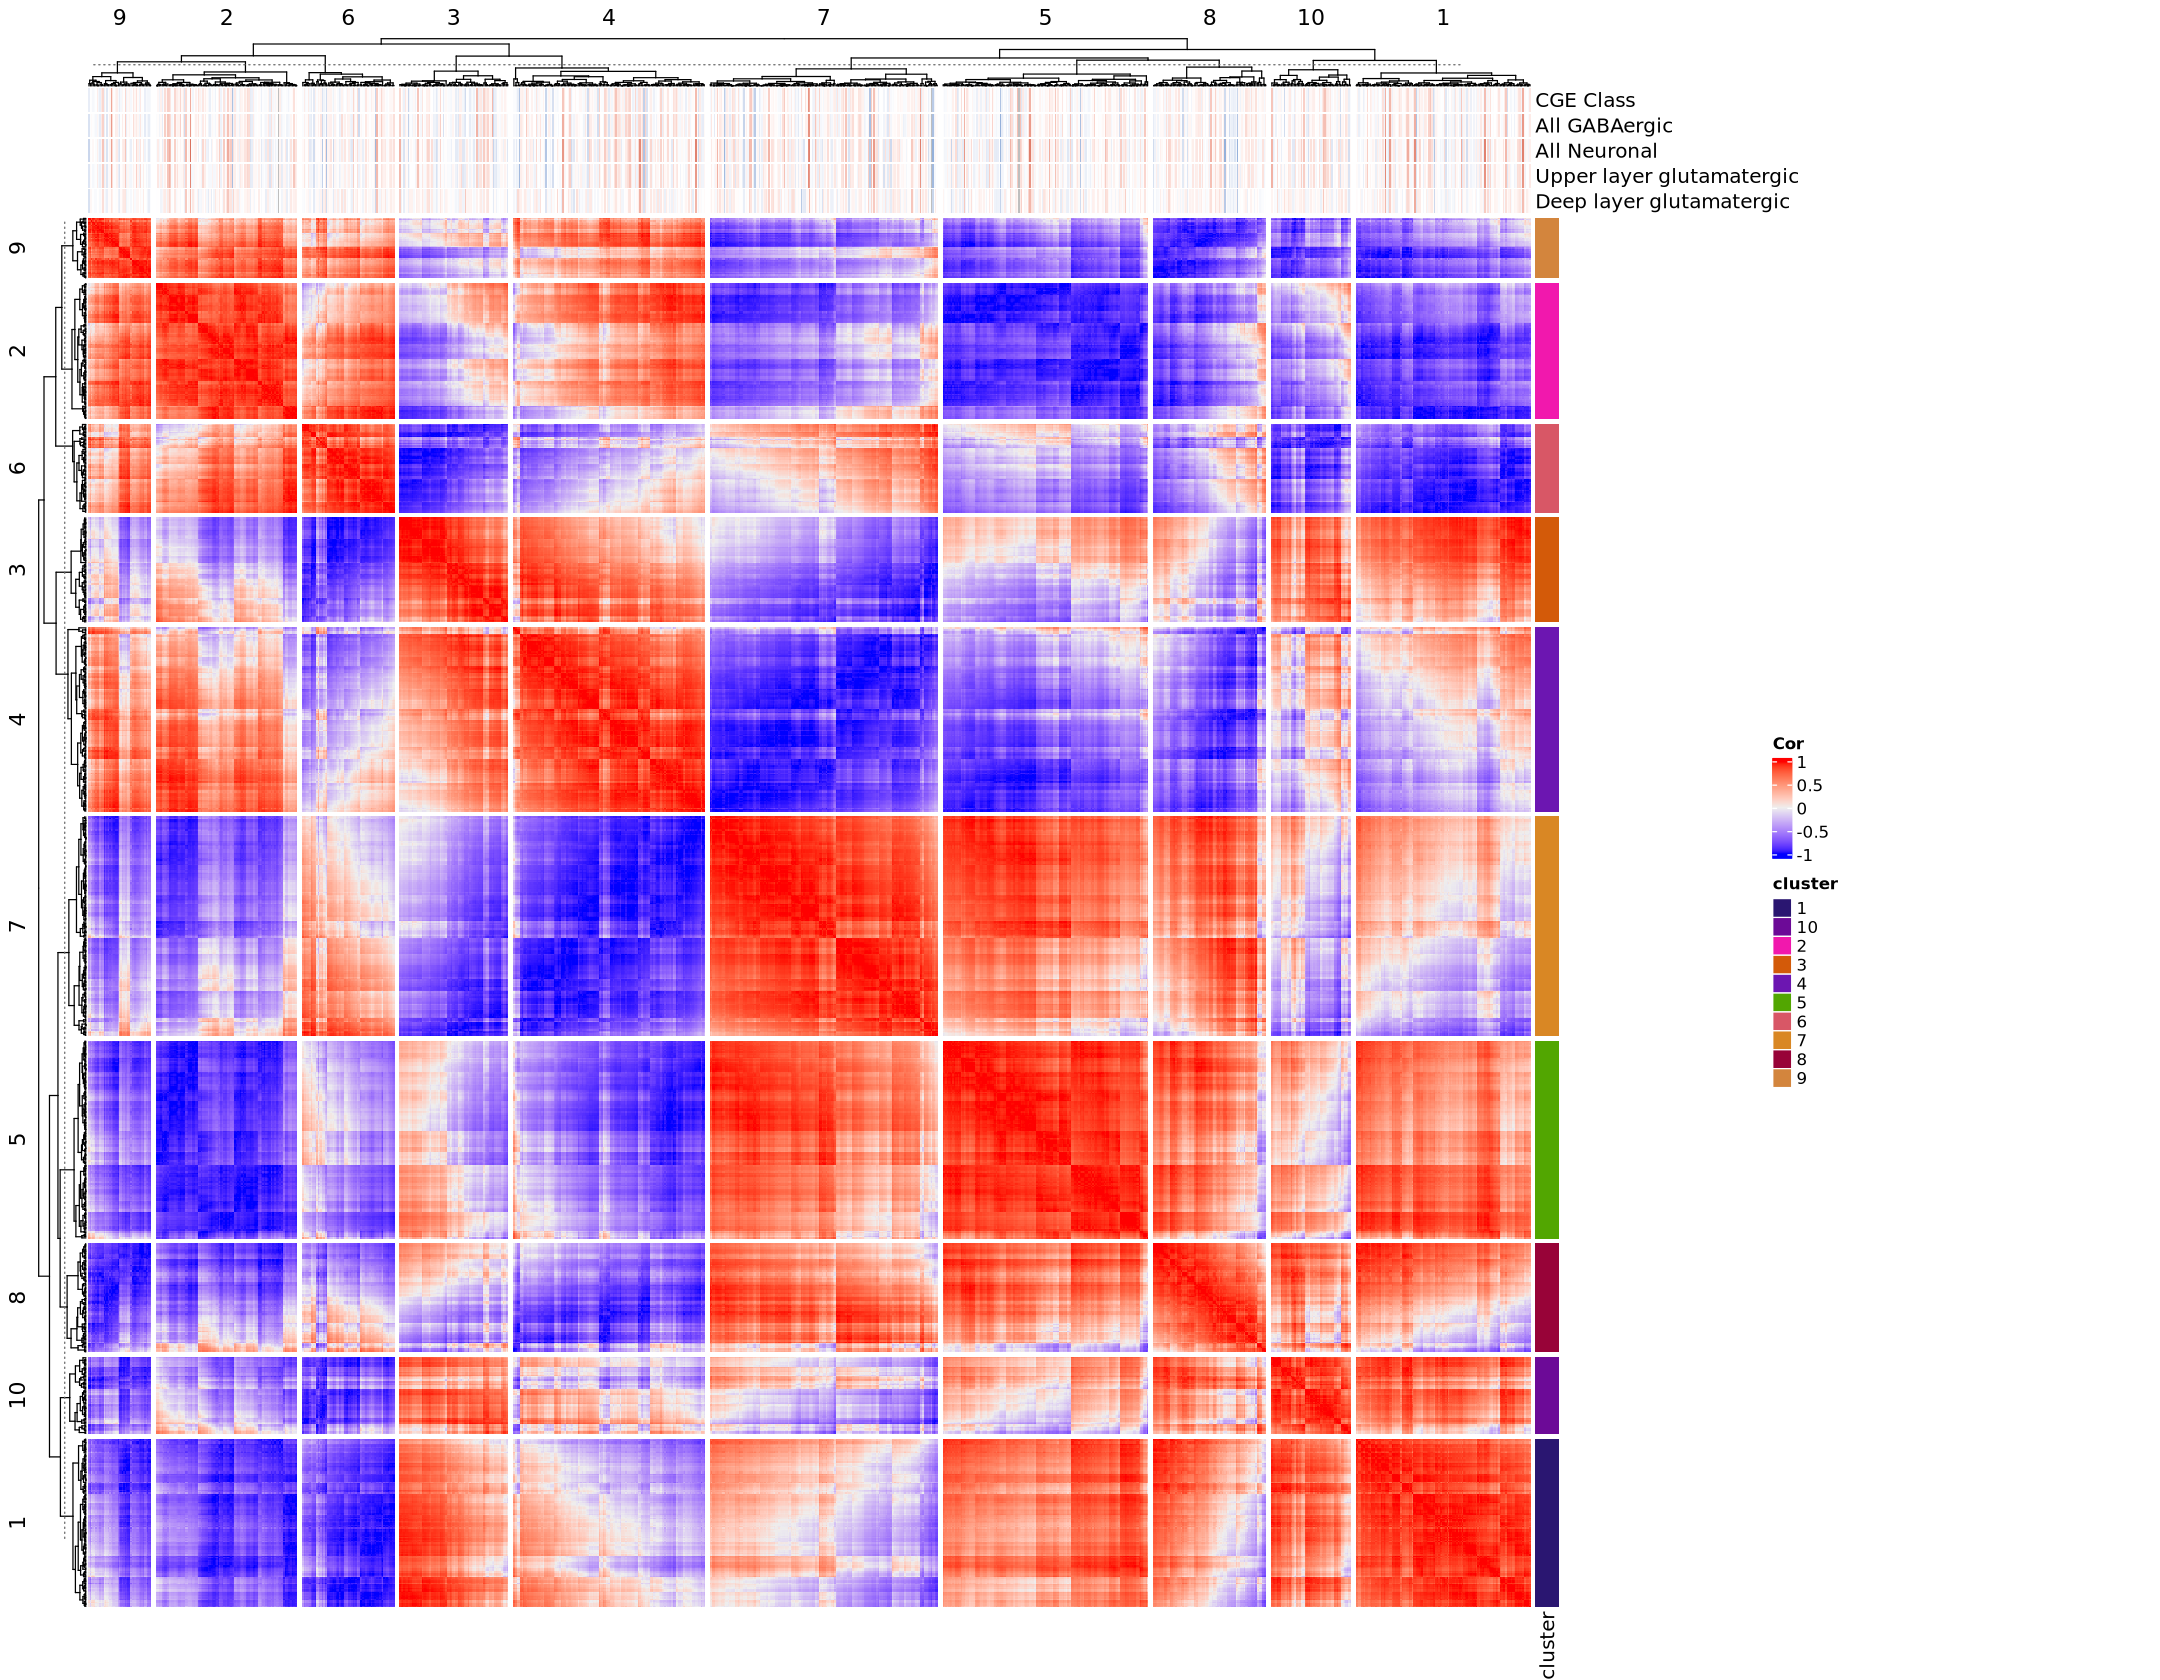

In [117]:
# Sample annotation (e.g. condition, cell type)
col_anno <- do.call(HeatmapAnnotation, c(
  ctype_corrs,
  list(col = lapply(ctype_corrs, function(x) 
    circlize::colorRamp2(c(-1, 0, 1), c("#3A7EC0", "white", "#C1392B"))
  )),
  show_legend = FALSE
))

row_anno <- rowAnnotation(
  cluster = as.character(clusters) # ,
#   col = list(cluster = setNames(
#     RColorBrewer::brewer.pal(k, "Set1"),
#     as.character(1:k)
#   ))
)

options(repr.plot.width=18, repr.plot.height=14)

ht <- Heatmap(
  corr_mat_subset,
  name            = "Cor",
  top_annotation  = col_anno,
  right_annotation = row_anno,
#   cluster_rows    = hc,           # pass your hclust object
#   cluster_columns = hc,
  show_row_names  = FALSE,        # hide if many exons
  show_column_names = FALSE,
  row_split = clusters,     # draws gaps between clusters
  column_split = clusters,
  border = FALSE
)

draw(ht, padding = unit(c(2, 2, 2, 70), "mm"))  # increase right value until labels fit